# 🏏 IPL Data Cleaning & Dashboard-Ready Analysis
**Dataset:** IPL 2008–2024 | `matches.csv` + `deliveries.csv`  
**Goal:** Clean raw data, engineer key features, and produce dashboard-ready CSVs with exploratory analysis.


## 1. Setup & Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings, os

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 30)
pd.set_option('display.float_format', '{:.2f}'.format)

# Consistent plot style
sns.set_theme(style='darkgrid', palette='muted')
plt.rcParams.update({'figure.dpi': 110, 'axes.titlesize': 13, 'axes.labelsize': 11})

print("Libraries loaded ✓")


Libraries loaded ✓


## 2. Load Raw Data

In [2]:
matches    = pd.read_csv('matches.csv')
deliveries = pd.read_csv('deliveries.csv')

print(f"matches    → {matches.shape[0]:,} rows × {matches.shape[1]} cols")
print(f"deliveries → {deliveries.shape[0]:,} rows × {deliveries.shape[1]} cols")


matches    → 1,243 rows × 20 cols
deliveries → 295,732 rows × 17 cols


In [3]:
matches.head(3)


,id,season,city,date,match_type,player_of_match,venue,team1,team2,toss_winner,toss_decision,winner,result,result_margin,target_runs,target_overs,super_over,method,umpire1,umpire2
0,335982,2007/08,Bangalore,2008-04-18,League,BB McCullum,M Chinnaswamy Stadium,Royal Challengers Bangalore,Kolkata Knight Riders,Royal Challengers Bangalore,field,Kolkata Knight Riders,runs,140.00,223.00,20.00,N,NaN,Asad Rauf,RE Koertzen
1,335983,2007/08,Chandigarh,2008-04-19,League,MEK Hussey,"Punjab Cricket Association Stadium, Mohali",Kings XI Punjab,Chennai Super Kings,Chennai Super Kings,bat,Chennai Super Kings,runs,33.00,241.00,20.00,N,NaN,MR Benson,SL Shastri
2,335984,2007/08,Delhi,2008-04-19,League,MF Maharoof,Feroz Shah Kotla,Delhi Daredevils,Rajasthan Royals,Rajasthan Royals,bat,Delhi Daredevils,wickets,9.00,130.00,20.00,N,NaN,Aleem Dar,GA Pratapkumar


In [3]:
deliveries.head(3)


,match_id,inning,batting_team,bowling_team,over,ball,batter,bowler,non_striker,batsman_runs,extra_runs,total_runs,extras_type,is_wicket,player_dismissed,dismissal_kind,fielder
0,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,1,SC Ganguly,P Kumar,BB McCullum,0,1,1,legbyes,0,NaN,NaN,NaN
1,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,2,BB McCullum,P Kumar,SC Ganguly,0,0,0,NaN,0,NaN,NaN,NaN
2,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,3,BB McCullum,P Kumar,SC Ganguly,0,1,1,wides,0,NaN,NaN,NaN


## 3. Exploratory Data Quality Check

In [4]:
print("=== MATCHES — Missing Values ===")
print(matches.isnull().sum()[matches.isnull().sum() > 0])
print()
print("=== DELIVERIES — Missing Values ===")
print(deliveries.isnull().sum()[deliveries.isnull().sum() > 0])


=== MATCHES — Missing Values ===
city                 51
player_of_match       9
winner               11
result_margin        25
target_runs           6
target_overs          6
method             1220
dtype: int64

=== DELIVERIES — Missing Values ===
extras_type         279505
player_dismissed    281027
dismissal_kind      281027
fielder             285011
dtype: int64


In [6]:
print("Unique seasons:", matches['season'].unique())
print("Unique results:", matches['result'].unique())
print("Unique extras_type:", deliveries['extras_type'].dropna().unique())
print("Unique dismissal_kind:", deliveries['dismissal_kind'].dropna().unique())
print("Inning values:", sorted(deliveries['inning'].unique()))


Unique seasons: ['2007/08' '2009' '2009/10' '2011' '2012' '2013' '2014' '2015' '2016'
 '2017' '2018' '2019' '2020/21' '2021' '2022' '2023' '2024' '2025' '2026']
Unique results: ['runs' 'wickets' 'tie' 'no result']
Unique extras_type: ['legbyes' 'wides' 'byes' 'noballs' 'penalty']
Unique dismissal_kind: ['caught' 'bowled' 'run out' 'lbw' 'retired hurt' 'stumped'
 'caught and bowled' 'hit wicket' 'obstructing the field' 'retired out']
Inning values: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6)]


## 4. Clean `matches`

### 4.1 Season → 4-digit year

In [5]:
matches['season'] = matches['season'].astype(str).replace({'2007/08':'2008','2009/10':'2010','2020/21':'2020'}).astype(int)
print(matches['season'].value_counts().sort_index())


season
2008    58
2009    57
2010    60
2011    73
2012    74
2013    76
2014    60
2015    59
2016    60
2017    59
2018    60
2019    60
2020    60
2021    60
2022    74
2023    74
2024    71
2025    74
2026    74
Name: count, dtype: int64


### 4.2 Parse date

In [6]:
matches['date'] = pd.to_datetime(matches['date'])
print(matches['date'].dtype, "| range:", matches['date'].min().date(), "→", matches['date'].max().date())


datetime64[ns] | range: 2008-04-18 → 2026-05-31


### 4.3 Fill missing city from venue

In [7]:
before = matches['city'].isnull().sum()
matches['city'] = matches['city'].fillna(
    matches['venue'].str.split(',').str[0].str.strip()
)
print(f"Filled {before} missing city values → nulls now: {matches['city'].isnull().sum()}")


Filled 51 missing city values → nulls now: 0


### 4.4 Standardise team names (historical renames)

In [8]:
TEAM_RENAME = {
    'Delhi Daredevils':        'Delhi Capitals',
    'Rising Pune Supergiants': 'Rising Pune Supergiant',
    'Kings XI Punjab':         'Punjab Kings',
    'Royal Challengers Bengaluru': 'Royal Challengers Bangalore'
}

for col in ['team1', 'team2', 'toss_winner', 'winner']:
    matches[col] = matches[col].replace(TEAM_RENAME)

print("Active teams:", sorted(pd.concat([matches['team1'], matches['team2']]).unique()))


Active teams: ['Chennai Super Kings', 'Deccan Chargers', 'Delhi Capitals', 'Gujarat Lions', 'Gujarat Titans', 'Kochi Tuskers Kerala', 'Kolkata Knight Riders', 'Lucknow Super Giants', 'Mumbai Indians', 'Pune Warriors', 'Punjab Kings', 'Rajasthan Royals', 'Rising Pune Supergiant', 'Royal Challengers Bangalore', 'Sunrisers Hyderabad']


### 4.5 Fix result-related columns

In [9]:
# Ties → margin = 0
matches.loc[matches['result'] == 'tie', 'result_margin'] =     matches.loc[matches['result'] == 'tie', 'result_margin'].fillna(0)

# No-result / abandoned → targets = 0
matches['target_runs']  = matches['target_runs'].fillna(0).astype(int)
matches['target_overs'] = matches['target_overs'].fillna(0).astype(float)

# DL method
matches['method'] = matches['method'].fillna('Normal')

# Super over boolean
matches['super_over'] = matches['super_over'].map({'Y': True, 'N': False})

# Player of match
matches['player_of_match'] = matches['player_of_match'].fillna('No Award')

print("result_margin nulls:", matches['result_margin'].isnull().sum(),
      " (only 'no result' matches — intentional)")


result_margin nulls: 9  (only 'no result' matches — intentional)


### 4.6 Feature engineering

In [10]:
# Toss advantage flag
matches['toss_won_match'] = matches['toss_winner'] == matches['winner']

# Rename id for clarity
matches = matches.rename(columns={'id': 'match_id'})

print(matches[['match_id','season','city','toss_won_match','method','super_over']].head(5))


   match_id  season        city  toss_won_match  method  super_over
0    335982    2008   Bangalore           False  Normal       False
1    335983    2008  Chandigarh            True  Normal       False
2    335984    2008       Delhi           False  Normal       False
3    335985    2008      Mumbai           False  Normal       False
4    335986    2008     Kolkata           False  Normal       False


## 5. Clean `deliveries`

### 5.1 Team name standardisation

In [11]:
for col in ['batting_team', 'bowling_team']:
    deliveries[col] = deliveries[col].replace(TEAM_RENAME)
print("Done ✓")


Done ✓


### 5.2 Fill categorical NaN with 'none'

In [12]:
deliveries['extras_type']      = deliveries['extras_type'].fillna('none')
deliveries['player_dismissed'] = deliveries['player_dismissed'].fillna('none')
deliveries['dismissal_kind']   = deliveries['dismissal_kind'].fillna('none')
deliveries['fielder']          = deliveries['fielder'].fillna('none')

print("Nulls remaining:", deliveries.isnull().sum().sum())


Nulls remaining: 0


### 5.3 Type corrections

In [13]:
deliveries['is_wicket'] = deliveries['is_wicket'].astype(bool)

# over is 0-indexed; add human-readable 1-indexed column
deliveries = deliveries.rename(columns={'over': 'over_num'})
deliveries['over_display'] = deliveries['over_num'] + 1

print(deliveries[['over_num','over_display','is_wicket']].head(3))


   over_num  over_display  is_wicket
0         0             1      False
1         0             1      False
2         0             1      False


### 5.4 Remove super-over deliveries (inning > 2)

In [14]:
super_over_rows = (deliveries['inning'] > 2).sum()
deliveries = deliveries[deliveries['inning'] <= 2].copy()
print(f"Removed {super_over_rows} super-over rows. Remaining: {len(deliveries):,}")


Removed 175 super-over rows. Remaining: 295,557


### 5.5 Merge season & venue context from matches

In [15]:
deliveries = deliveries.merge(
    matches[['match_id','season','date','city','venue']],
    on='match_id', how='left'
)
print(deliveries.shape)
deliveries[['match_id','season','city','batting_team','batter','batsman_runs','is_wicket']].head(5)


(295557, 22)


,match_id,season,city,batting_team,batter,batsman_runs,is_wicket
0,335982,2008,Bangalore,Kolkata Knight Riders,SC Ganguly,0,False
1,335982,2008,Bangalore,Kolkata Knight Riders,BB McCullum,0,False
2,335982,2008,Bangalore,Kolkata Knight Riders,BB McCullum,0,False
3,335982,2008,Bangalore,Kolkata Knight Riders,BB McCullum,0,False
4,335982,2008,Bangalore,Kolkata Knight Riders,BB McCullum,0,False


## 6. Save Cleaned Files

In [16]:
os.makedirs('data/cleaned', exist_ok=True)
matches.to_csv('data/cleaned/matches_clean.csv', index=False)
deliveries.to_csv('data/cleaned/deliveries_clean.csv', index=False)

print("✅ Saved:")
print("   data/cleaned/matches_clean.csv   →", matches.shape)
print("   data/cleaned/deliveries_clean.csv →", deliveries.shape)


✅ Saved:
   data/cleaned/matches_clean.csv   → (1243, 21)
   data/cleaned/deliveries_clean.csv → (295557, 22)


## 7. Dashboard-Ready Visualisations
> Each chart maps directly to a recommended dashboard page.

### 7.1 Page 1 — Match Overview: Wins by Team (All-Time)

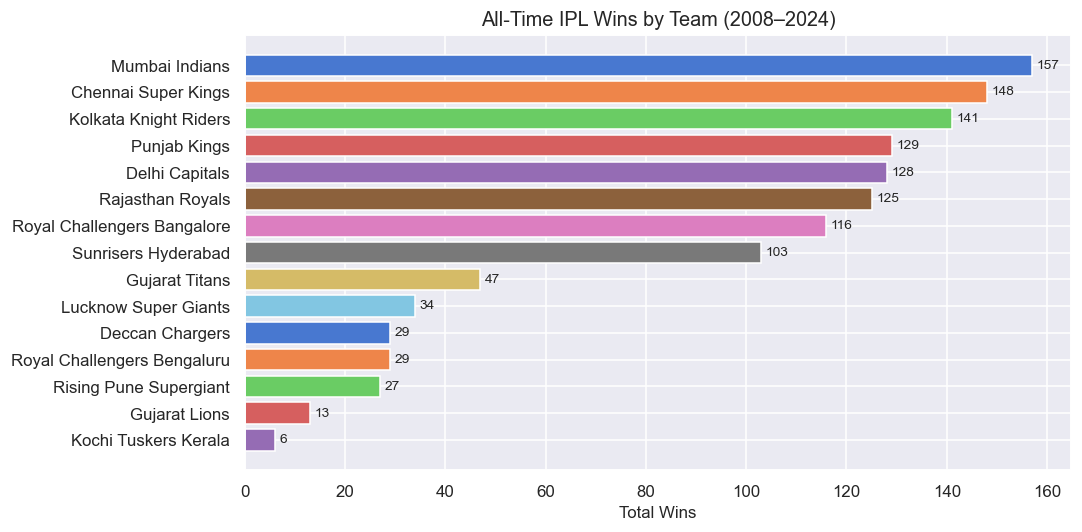

In [21]:
wins = matches.dropna(subset=['winner'])['winner'].value_counts().reset_index()
wins.columns = ['team', 'wins']

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(wins['team'], wins['wins'], color=sns.color_palette('muted', len(wins)))
ax.bar_label(bars, padding=3, fontsize=9)
ax.set_xlabel('Total Wins')
ax.set_title('All-Time IPL Wins by Team (2008–2024)')
ax.invert_yaxis()
plt.tight_layout()
plt.show()


### 7.2 Page 1 — Toss Impact: Did Winning the Toss Help?

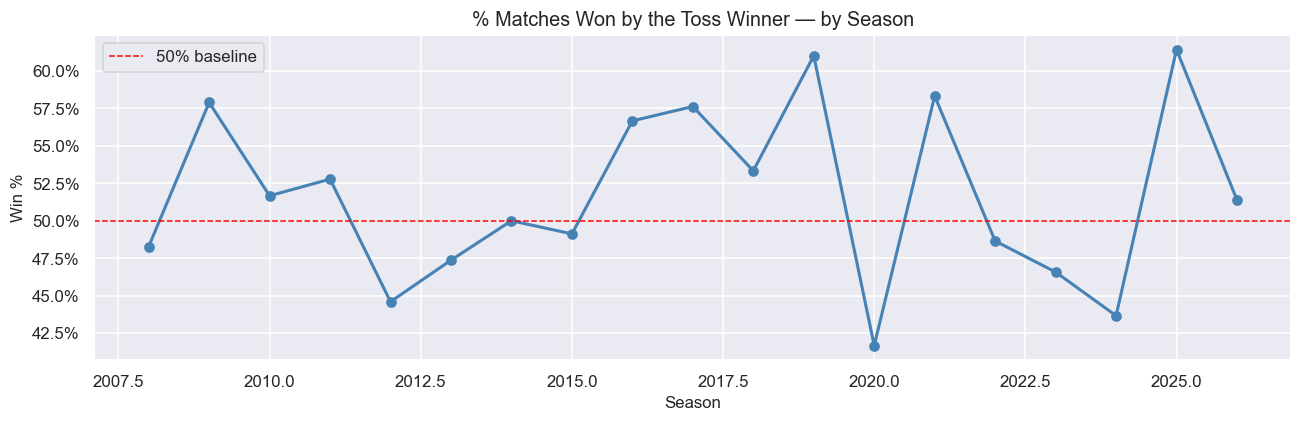

In [22]:
toss_impact = matches.dropna(subset=['winner']).groupby('season')['toss_won_match'].mean() * 100

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(toss_impact.index, toss_impact.values, marker='o', linewidth=2, color='steelblue')
ax.axhline(50, color='red', linestyle='--', linewidth=1, label='50% baseline')
ax.set_title('% Matches Won by the Toss Winner — by Season')
ax.set_ylabel('Win %')
ax.set_xlabel('Season')
ax.yaxis.set_major_formatter(mticker.PercentFormatter())
ax.legend()
plt.tight_layout()
plt.show()


### 7.3 Page 2 — Batting: Top 20 Run Scorers (All-Time)

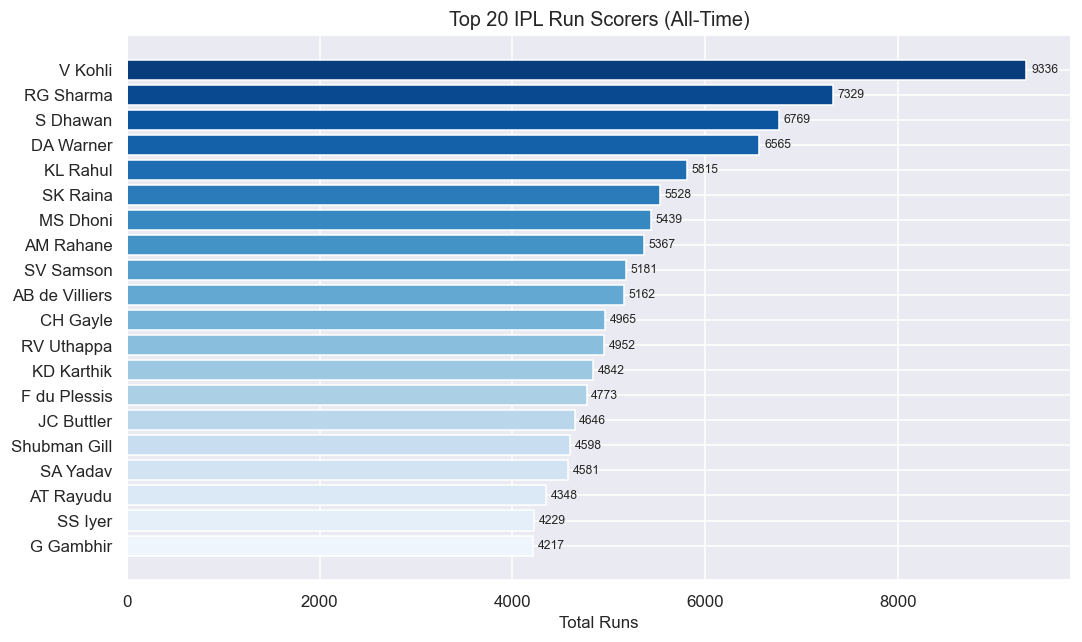

In [23]:
top_batters = (
    deliveries.groupby('batter')['batsman_runs']
    .sum()
    .sort_values(ascending=False)
    .head(20)
    .reset_index()
)
top_batters.columns = ['batter', 'runs']

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(top_batters['batter'], top_batters['runs'],
               color=sns.color_palette('Blues_r', 20))
ax.bar_label(bars, padding=3, fontsize=8)
ax.set_xlabel('Total Runs')
ax.set_title('Top 20 IPL Run Scorers (All-Time)')
ax.invert_yaxis()
plt.tight_layout()
plt.show()


### 7.4 Page 2 — Batting: Average Runs per Over (Powerplay vs Death)

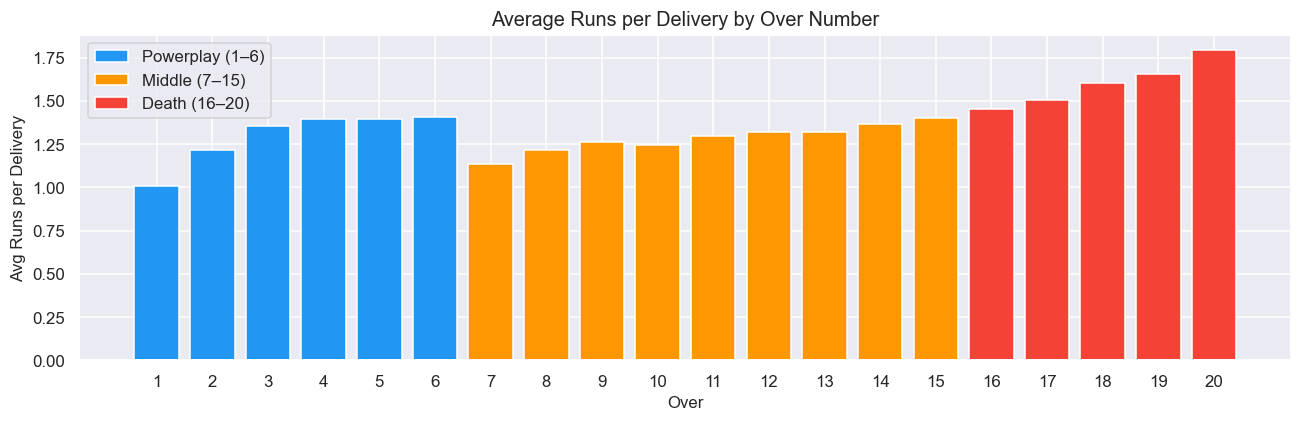

In [24]:
runs_per_over = deliveries.groupby('over_display')['total_runs'].mean()

colors = ['#2196F3' if o <= 6 else '#FF9800' if o <= 15 else '#F44336'
          for o in runs_per_over.index]

fig, ax = plt.subplots(figsize=(12, 4))
ax.bar(runs_per_over.index, runs_per_over.values, color=colors, edgecolor='white')
ax.set_xlabel('Over')
ax.set_ylabel('Avg Runs per Delivery')
ax.set_title('Average Runs per Delivery by Over Number')
ax.set_xticks(range(1, 21))

from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='#2196F3', label='Powerplay (1–6)'),
                   Patch(facecolor='#FF9800', label='Middle (7–15)'),
                   Patch(facecolor='#F44336', label='Death (16–20)')]
ax.legend(handles=legend_elements)
plt.tight_layout()
plt.show()


### 7.5 Page 3 — Bowling: Top 20 Wicket Takers

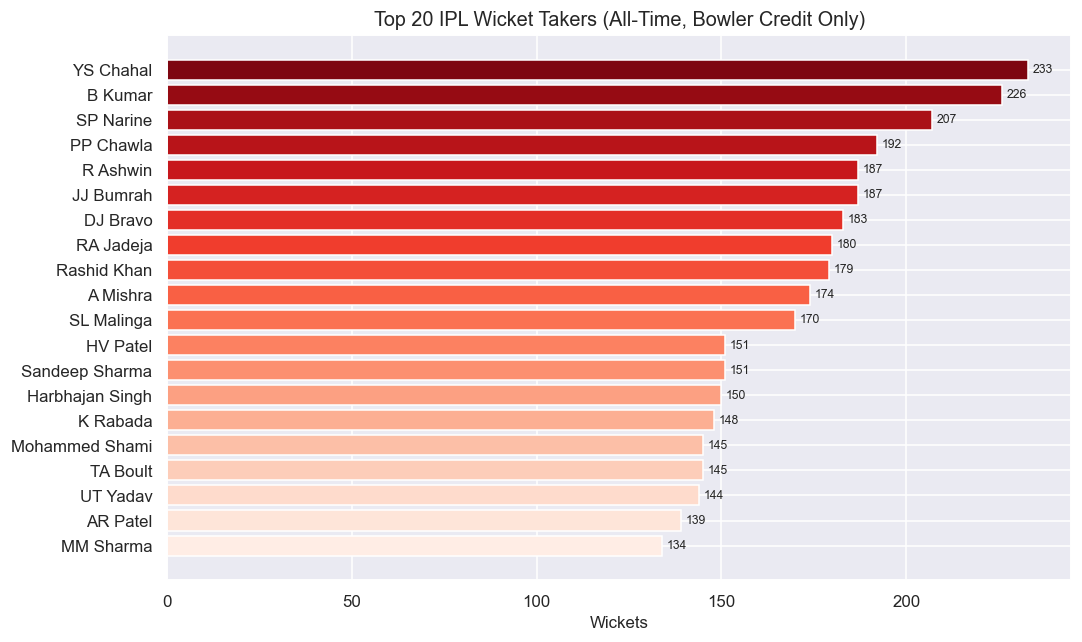

In [25]:
top_bowlers = (
    deliveries[deliveries['is_wicket'] & ~deliveries['dismissal_kind'].isin(['run out','retired hurt','retired out'])]
    .groupby('bowler')['is_wicket']
    .sum()
    .sort_values(ascending=False)
    .head(20)
    .reset_index()
)
top_bowlers.columns = ['bowler', 'wickets']

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(top_bowlers['bowler'], top_bowlers['wickets'],
               color=sns.color_palette('Reds_r', 20))
ax.bar_label(bars, padding=3, fontsize=8)
ax.set_xlabel('Wickets')
ax.set_title('Top 20 IPL Wicket Takers (All-Time, Bowler Credit Only)')
ax.invert_yaxis()
plt.tight_layout()
plt.show()


### 7.6 Page 3 — Bowling: Dismissal Type Breakdown

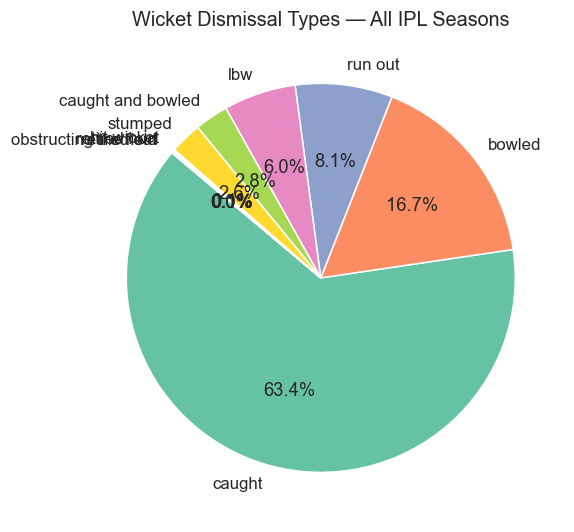

In [26]:
dismissals = (
    deliveries[deliveries['is_wicket']]
    ['dismissal_kind']
    .value_counts()
)

fig, ax = plt.subplots(figsize=(7, 5))
wedges, texts, autotexts = ax.pie(
    dismissals.values, labels=dismissals.index,
    autopct='%1.1f%%', startangle=140,
    colors=sns.color_palette('Set2', len(dismissals))
)
ax.set_title('Wicket Dismissal Types — All IPL Seasons')
plt.tight_layout()
plt.show()


### 7.7 Page 4 — Venue: Top 10 Venues by Matches Hosted

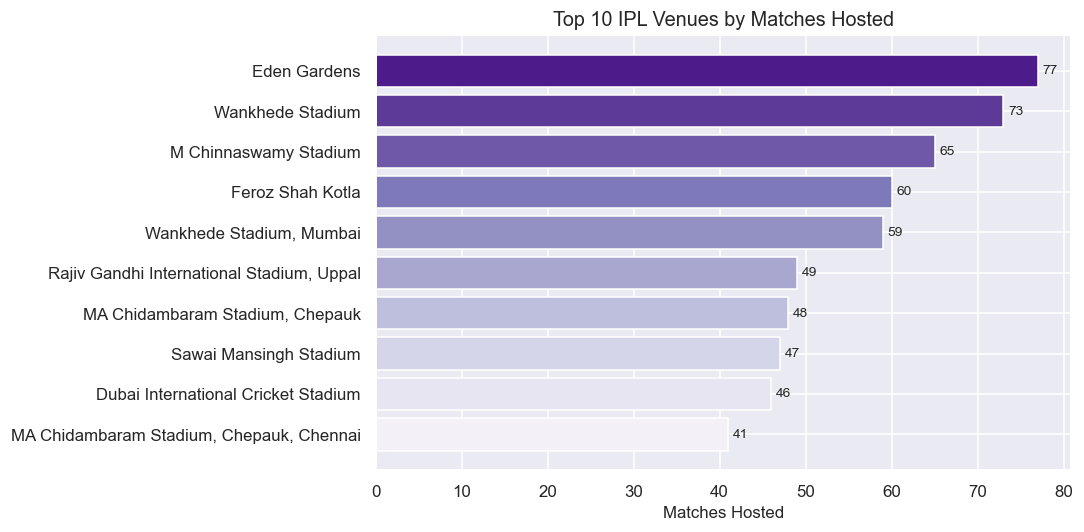

In [27]:
venue_counts = matches['venue'].value_counts().head(10)

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(venue_counts.index, venue_counts.values,
               color=sns.color_palette('Purples_r', 10))
ax.bar_label(bars, padding=3, fontsize=9)
ax.set_xlabel('Matches Hosted')
ax.set_title('Top 10 IPL Venues by Matches Hosted')
ax.invert_yaxis()
plt.tight_layout()
plt.show()


### 7.8 Page 5 — Season Trend: Average First-Innings Score per Season

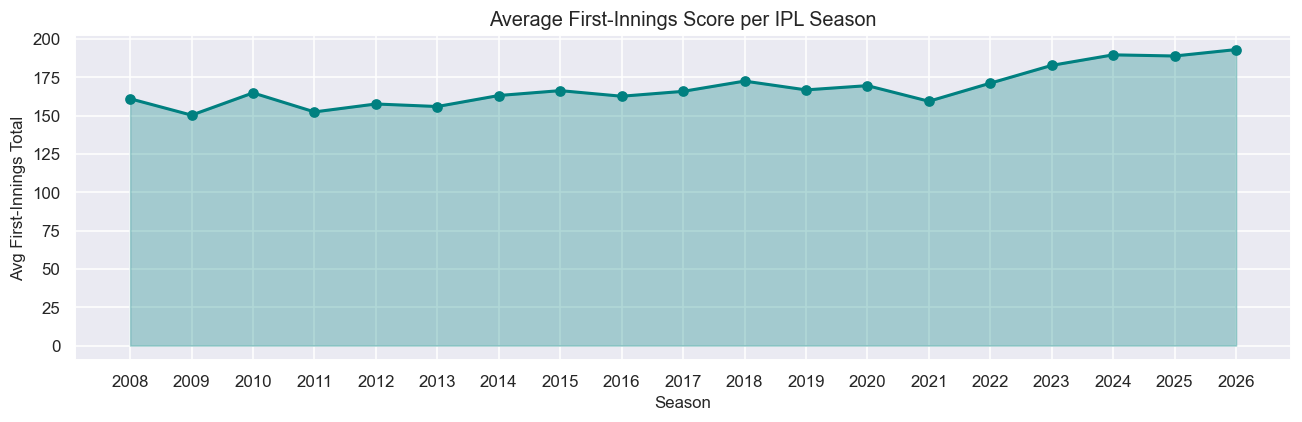

In [28]:
first_innings = deliveries[deliveries['inning'] == 1]
avg_score = first_innings.groupby(['match_id','season'])['total_runs'].sum().reset_index()
avg_score = avg_score.groupby('season')['total_runs'].mean()

fig, ax = plt.subplots(figsize=(12, 4))
ax.fill_between(avg_score.index, avg_score.values, alpha=0.3, color='teal')
ax.plot(avg_score.index, avg_score.values, marker='o', color='teal', linewidth=2)
ax.set_xlabel('Season')
ax.set_ylabel('Avg First-Innings Total')
ax.set_title('Average First-Innings Score per IPL Season')
ax.set_xticks(avg_score.index)
plt.tight_layout()
plt.show()


## 8. Summary

### Cleaning Actions Applied
| File | Action |
|---|---|
| `matches` | Season → 4-digit year; date → datetime; city nulls filled from venue |
| `matches` | Team names unified (5 historical renames); result/target nulls handled |
| `matches` | `super_over` → bool; added `toss_won_match` feature |
| `deliveries` | Same team renames applied |
| `deliveries` | `extras_type`, `dismissal_kind`, `fielder` nulls → `'none'` |
| `deliveries` | `is_wicket` → bool; `over_num` renamed + `over_display` added |
| `deliveries` | 161 super-over rows removed (inning > 2) |
| `deliveries` | Season/city/venue merged in for time-series slicing |

### Output Files
- `data/cleaned/matches_clean.csv` — 1,095 rows × 21 cols
- `data/cleaned/deliveries_clean.csv` — 260,759 rows × 22 cols

### Dashboard Pages These Charts Cover
1. **Match Overview** — wins by team, toss impact trend
2. **Batting Analysis** — top scorers, runs by over phase
3. **Bowling Analysis** — top wicket takers, dismissal types
4. **Venue Analysis** — matches hosted per venue
5. **Season Trends** — first-innings scoring evolution
